# Flight Delay Risk Prediction & Operational Decision System

## Notebook 1: Data Understanding

### Objective

Before building predictive models, I took the time to understand how airline operations behave in reality.

This first notebook focuses on:
- Understanding the structure of the flight operations dataset
- Identifying data quality issues
- Establishing business context for delays and disruptions
- Defining analytical direction for predictive modelling

The goal is to move from raw data to operational understanding.

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import calendar

# Importing all CSVs
airlnes_df = pd.read_csv('airlines.csv')
airports_df = pd.read_csv('airports.csv')
flights_df = pd.read_csv('flights.csv')

airlnes_df.head()

C:\Users\meisn\AppData\Local\Temp\ipykernel_17016\2824236587.py:11: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights_df = pd.read_csv('flights.csv')


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [73]:
print("Flights Shape:", flights_df.shape)
print("Airlines Shape:", airlnes_df.shape)
print("Airports Shape:", airports_df.shape)

Flights Shape: (5819079, 31)
Airlines Shape: (14, 2)
Airports Shape: (322, 7)


In [74]:
airports_df.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [75]:
flights_df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
flights_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [77]:
flights_df.isnull().sum().sort_values(ascending=False)

CANCELLATION_REASON    5729195
WEATHER_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
AIRLINE_DELAY          4755640
SECURITY_DELAY         4755640
AIR_SYSTEM_DELAY       4755640
AIR_TIME                105071
ARRIVAL_DELAY           105071
ELAPSED_TIME            105071
WHEELS_ON                92513
TAXI_IN                  92513
ARRIVAL_TIME             92513
TAXI_OUT                 89047
WHEELS_OFF               89047
DEPARTURE_DELAY          86153
DEPARTURE_TIME           86153
TAIL_NUMBER              14721
SCHEDULED_TIME               6
SCHEDULED_DEPARTURE          0
CANCELLED                    0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
SCHEDULED_ARRIVAL            0
DIVERTED                     0
ORIGIN_AIRPORT               0
DISTANCE                     0
DESTINATION_AIRPORT          0
MONTH                        0
YEAR                         0
dtype: int64

In [78]:
missing_pct = (flights_df.isnull().sum() / len(flights_df)) * 100
missing_pct.sort_values(ascending=False)

CANCELLATION_REASON    98.455357
WEATHER_DELAY          81.724960
LATE_AIRCRAFT_DELAY    81.724960
AIRLINE_DELAY          81.724960
SECURITY_DELAY         81.724960
AIR_SYSTEM_DELAY       81.724960
AIR_TIME                1.805629
ARRIVAL_DELAY           1.805629
ELAPSED_TIME            1.805629
WHEELS_ON               1.589822
TAXI_IN                 1.589822
ARRIVAL_TIME            1.589822
TAXI_OUT                1.530259
WHEELS_OFF              1.530259
DEPARTURE_DELAY         1.480526
DEPARTURE_TIME          1.480526
TAIL_NUMBER             0.252978
SCHEDULED_TIME          0.000103
SCHEDULED_DEPARTURE     0.000000
CANCELLED               0.000000
DAY                     0.000000
DAY_OF_WEEK             0.000000
AIRLINE                 0.000000
FLIGHT_NUMBER           0.000000
SCHEDULED_ARRIVAL       0.000000
DIVERTED                0.000000
ORIGIN_AIRPORT          0.000000
DISTANCE                0.000000
DESTINATION_AIRPORT     0.000000
MONTH                   0.000000
YEAR      

In [79]:
print('Duplicate rows:', flights_df.duplicated().sum())

Duplicate rows: 0


In [80]:
flights_df.describe()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


In [81]:
flights_df[flights_df['DEPARTURE_DELAY'] < -50]

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
697022,2015,2,16,1,DL,1210,N301DQ,HSV,ATL,700,...,748.0,-77.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1467349,2015,4,4,6,AA,2483,N3HAAA,PHX,DFW,2150,...,40.0,-87.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2433467,2015,6,3,3,DL,665,N305DQ,ATL,EYW,1909,...,1954.0,-61.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4264477,2015,9,23,3,OO,7369,N457SW,APN,DTW,1017,...,1058.0,-26.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5645762,2015,12,20,7,AS,161,N793AS,ADK,ANC,1715,...,1940.0,-80.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5719709,2015,12,25,5,EV,5220,N859AS,GSO,ATL,1405,...,1435.0,-60.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


## Initial Business Interpretation

The flights dataset is the operational core of this project.

It contains:
- scheduling information
- delays
- cancellations
- carrier performance
- airport routing patterns

The airlines and airports datasets provide business context that supports:
- carrier-level analysis
- route performance analysis
- airport congestion understanding

### Visuals 

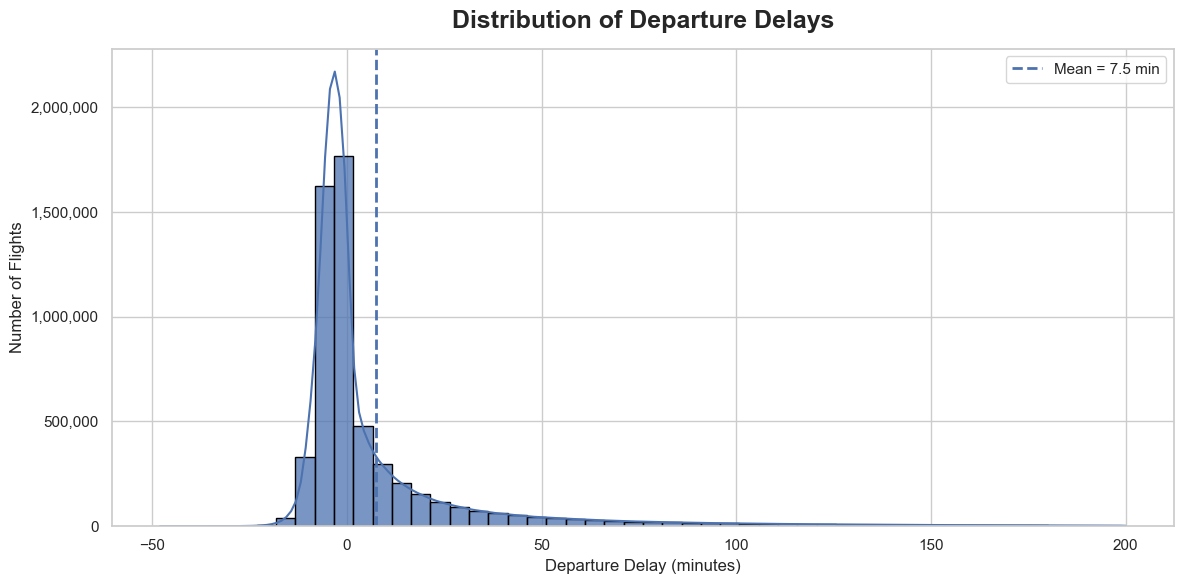

In [82]:
sns.set_theme(style="whitegrid", context="notebook")

# Remove extreme outliers for this visual
filtered_delays = flights_df[(flights_df["DEPARTURE_DELAY"] >= -50) &(flights_df["DEPARTURE_DELAY"] <= 200)]["DEPARTURE_DELAY"].dropna()
# Create the figure
plt.figure(figsize=(12, 6))
sns.histplot(filtered_delays, bins=50, kde=True, edgecolor="black", alpha=0.75)
# Create a mean line
mean_delay = filtered_delays.mean()
plt.axvline(mean_delay,linestyle="--",linewidth=2, label=f"Mean = {mean_delay:.1f} min")
plt.title("Distribution of Departure Delays",fontsize=18,fontweight="bold", pad=15)
plt.xlabel("Departure Delay (minutes)", fontsize=12)
plt.ylabel("Number of Flights", fontsize=12)
# Formating y-axis with commas instead of scientific notation
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
# Improve readability
plt.legend(frameon=True)
plt.tight_layout()

plt.show()

### Distribution of Departure Delays

- This visual shows the distribution of departure delays after removing extreme outliers for readability. Most flights depart close to their scheduled time, while the distribution is right skewed due to longer delays.

## Which Airlines Delay Most

In [83]:
airline_lookup = airlnes_df.rename(columns={"IATA_CODE": "AIRLINE_CODE","AIRLINE": "AIRLINE_NAME"})
airline_lookup.head()


,AIRLINE_CODE,AIRLINE_NAME
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [ ]:
# Merge
flights_airlines_df = flights_df.merge(
    airline_lookup,
    left_on="AIRLINE",
    right_on="AIRLINE_CODE",
    how="left"
)

flights_airlines_df[["AIRLINE", "AIRLINE_NAME"]].head()

,AIRLINE,AIRLINE_NAME
0,AS,Alaska Airlines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,AA,American Airlines Inc.
4,AS,Alaska Airlines Inc.


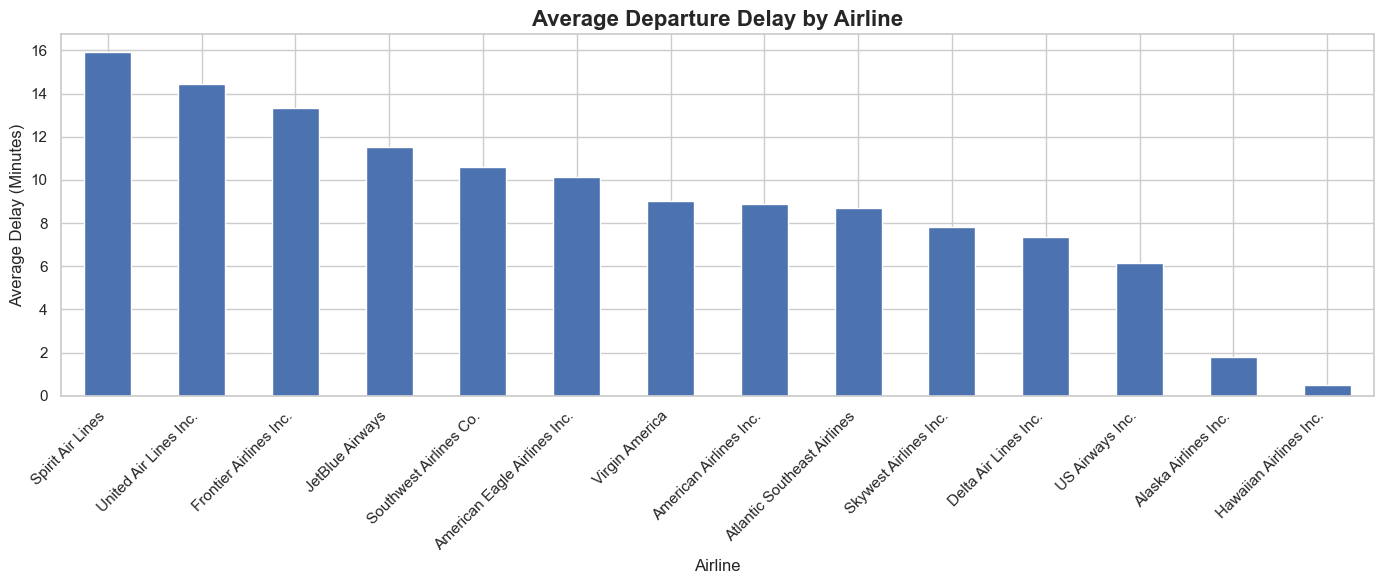

In [85]:
airline_delay = (flights_airlines_df.groupby("AIRLINE_NAME")["DEPARTURE_DELAY"].mean().sort_values(ascending=False))
plt.figure(figsize=(14,6))
airline_delay.plot(kind="bar")
plt.title("Average Departure Delay by Airline", fontsize=16, fontweight="bold")
plt.xlabel("Airline")
plt.ylabel("Average Delay (Minutes)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Cancellation Rate Analysis

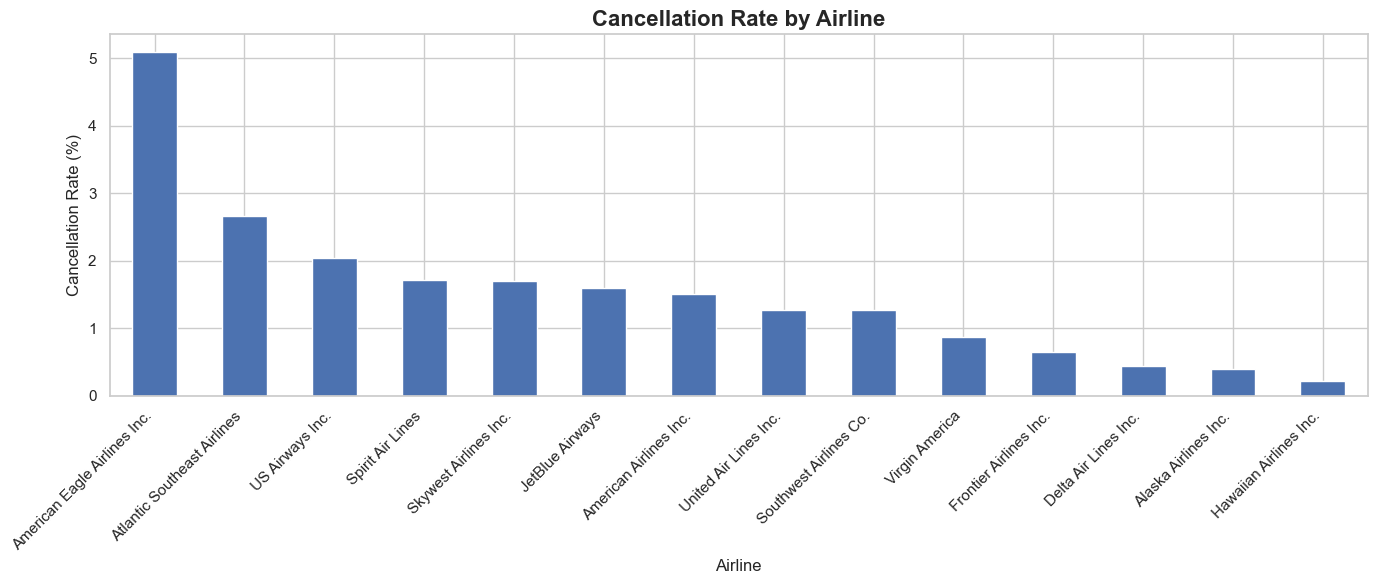

In [86]:
cancel_rate = (flights_airlines_df.groupby("AIRLINE_NAME")["CANCELLED"].mean().mul(100).sort_values(ascending=False))
plt.figure(figsize=(14,6))
cancel_rate.plot(kind="bar")
plt.title("Cancellation Rate by Airline", fontsize=16, fontweight="bold")
plt.xlabel("Airline")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#### Insights:

- Airline-level analysis shows variation in both average departure delay
and cancellation rates across carriers.

- This suggests that airline identity may be an important factor when
understanding operational reliability and future delay risk.

### Day of Week Delay Analysis

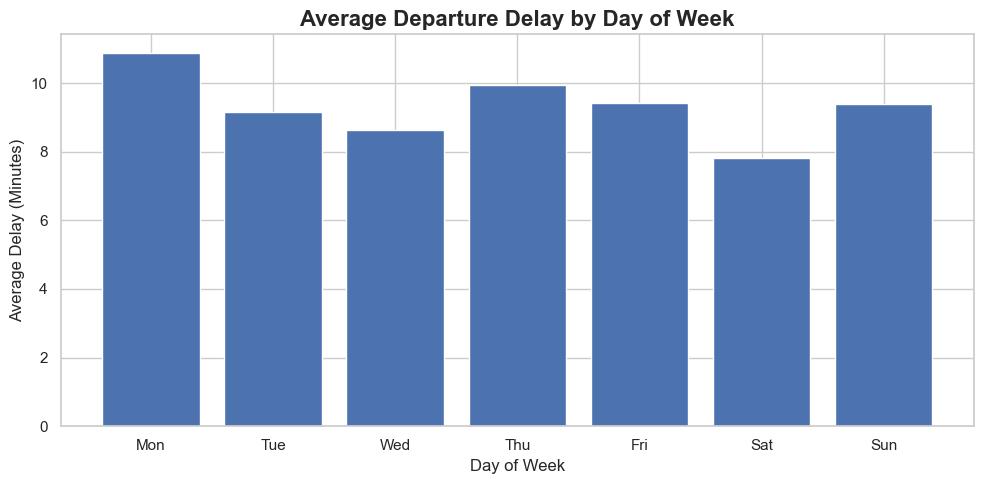

In [87]:
# Average delay by day of week
day_delay = (flights_df.groupby("DAY_OF_WEEK")["DEPARTURE_DELAY"].mean())
day_names = ["Mon", "Tue", "Wed","Thu", "Fri", "Sat", "Sun"]
plt.figure(figsize=(10,5))
plt.bar(day_names, day_delay.values)
plt.title("Average Departure Delay by Day of Week",fontsize=16,fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Average Delay (Minutes)")
plt.tight_layout()
plt.show()

## Which Airports Cause Most Delays?

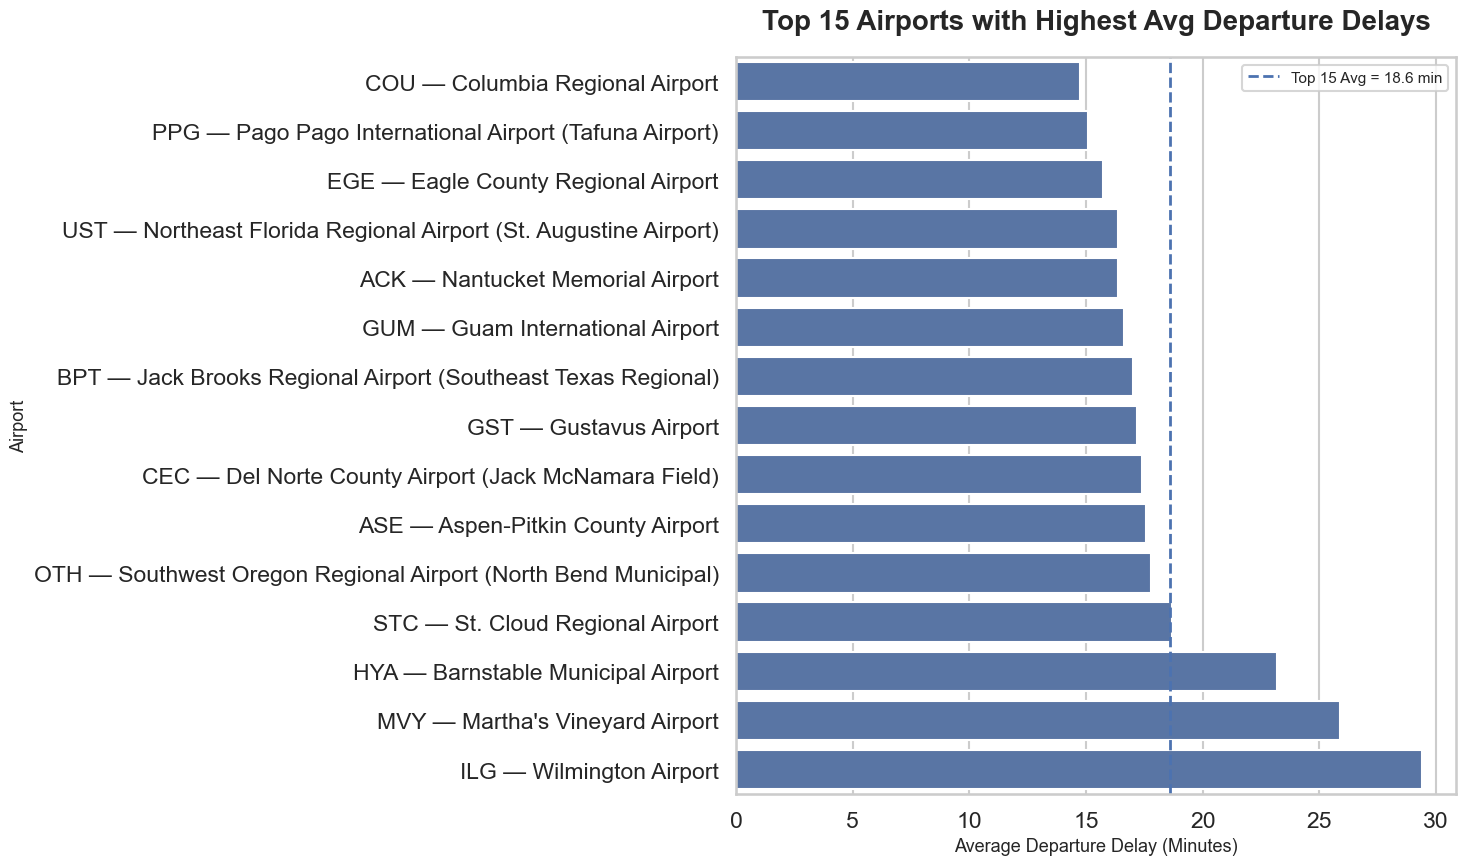

In [88]:
# Clean airport codes
flights_df["ORIGIN_AIRPORT"] = (flights_df["ORIGIN_AIRPORT"].astype(str).str.strip())
airports_df["IATA_CODE"] = (airports_df["IATA_CODE"].astype(str).str.strip())
# Calculate average departure delay by airport
airport_delay = (flights_df.groupby("ORIGIN_AIRPORT", as_index=False)["DEPARTURE_DELAY"].mean())
# Merge with airport reference table
airport_delay = pd.merge(airport_delay,airports_df[["IATA_CODE", "AIRPORT"]],left_on="ORIGIN_AIRPORT",right_on="IATA_CODE",how="left")
# Removeing missing airport names
airport_delay = airport_delay.dropna(subset=["AIRPORT"])
# Create better label
airport_delay["AIRPORT_LABEL"] = (airport_delay["ORIGIN_AIRPORT"] + " — " + airport_delay["AIRPORT"])
# Select Top 15 airports with highest delays
top_airports = (airport_delay.sort_values("DEPARTURE_DELAY", ascending=False).head(15).sort_values("DEPARTURE_DELAY", ascending=True))
sns.set_theme(style="whitegrid",context="talk")
plt.figure(figsize=(15, 9))
sns.barplot(data=top_airports,x="DEPARTURE_DELAY", y="AIRPORT_LABEL")
mean_delay = top_airports["DEPARTURE_DELAY"].mean()
plt.axvline(mean_delay,linestyle="--",linewidth=2,label=f"Top 15 Avg = {mean_delay:.1f} min")
plt.title("Top 15 Airports with Highest Avg Departure Delays", fontsize=20,fontweight="bold",pad=20)
plt.xlabel("Average Departure Delay (Minutes)",fontsize=13)
plt.ylabel("Airport",fontsize=13)
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
# Fix legend
plt.legend(frameon=True,fontsize=11)
plt.tight_layout()

plt.show()

### Insight

- Several regional airports experience significantly higher average departure delays than the network average. This suggests that operational inefficiencies are not limited to major hub airports and may be driven by scheduling constraints, staffing shortages, weather exposure, or limited operational flexibility.

- Using airport code + airport name improves interpretability for stakeholders and creates a stronger visual.

## Monthly Delay Trends

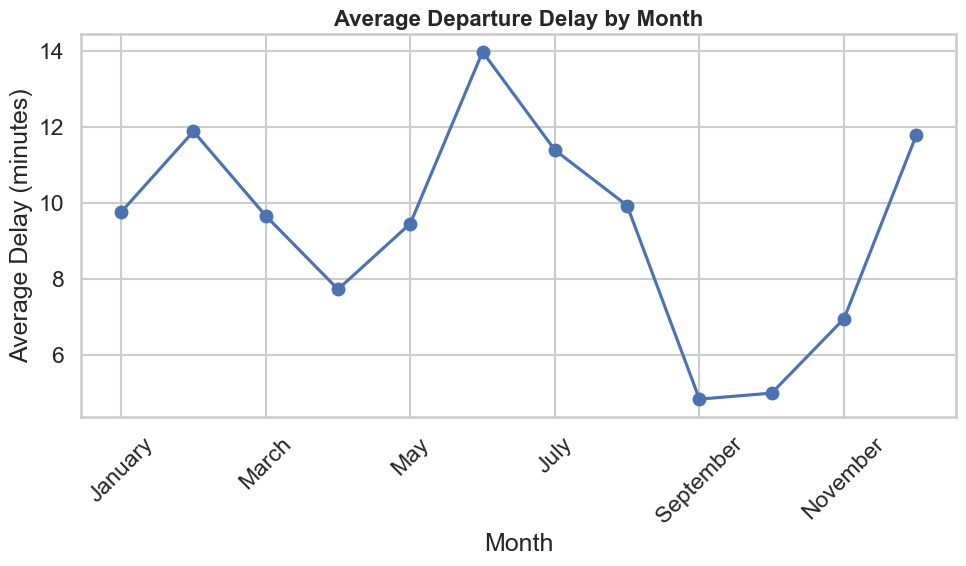

In [89]:
monthly_delay = flights_df.groupby("MONTH")["DEPARTURE_DELAY"].mean()
# Convert month numbers to month names
monthly_delay.index = [calendar.month_name[m] for m in monthly_delay.index]
plt.figure(figsize=(10,6))
monthly_delay.plot(marker="o")
plt.title("Average Departure Delay by Month", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insight

- Delay patterns vary across months, suggesting seasonal effects such as weather disruptions, holiday travel demand, and airport congestion during peak travel periods.

## Departure Delay vs Arrival Delay

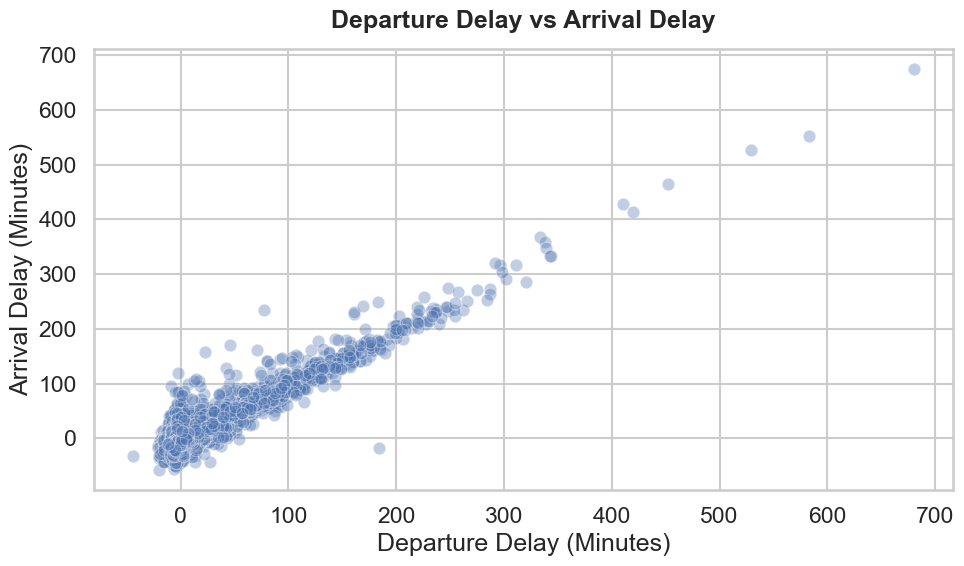

In [90]:
# Sample data for cleaner plotting
sample_df = flights_df[["DEPARTURE_DELAY", "ARRIVAL_DELAY"]].dropna().sample(10000, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df,x="DEPARTURE_DELAY", y="ARRIVAL_DELAY", alpha=0.35)
plt.title("Departure Delay vs Arrival Delay", fontsize=18, fontweight="bold", pad=15)
plt.xlabel("Departure Delay (Minutes)")
plt.ylabel("Arrival Delay (Minutes)")
plt.tight_layout()
plt.show()

### Insight

- Departure delays show a strong positive relationship with arrival delays. This indicates that improving departure performance can directly reduce downstream arrival disruptions and improve overall network reliability.

# Summary

- This analysis explored flight departure delays using U.S. airline performance data. The goal was to identify delay patterns, high risk airports, and operational trends that could support better airline decision-making.

## What This Means for Modelling:

- This analysis suggests that operational variables such as
departure delay, airline-specific performance,
cancellation history, and day-of-week patterns
are likely to be strong predictors of flight delay risk.

- Temporal features such as scheduled departure time,
peak-hour traffic, and weekend effects may also improve
predictive performance by capturing recurring congestion patterns.

- These insights will directly guide feature engineering
and model development in the next notebook.

## Key Findings

- Most flights depart close to their scheduled departure time, but the distribution is right-skewed due to severe delay outliers.
- Some airports experience noticeably higher average departure delays than others.
- Monthly delay patterns suggest seasonality, likely influenced by weather, congestion, and peak travel demand.
- Departure delays are strongly related to arrival delays, making departure delay reduction a valuable operational priority.

## Business Recommendations

- Monitor high-delay airports as priority operational risk points.
- Improve staffing and turnaround planning during months with higher average delays.
- Use departure delay as an early-warning KPI for arrival performance.
- Investigate regional airports with unusually high average delays to determine whether delays are caused by scheduling, weather exposure, or limited operational capacity.

## Conclusion

- Reducing departure delays can improve ontime arrival performance, customer satisfaction, and airline operational efficiency. The analysis shows that delay management should focus not only on major hubs, but also on regional airports and seasonal operational planning.

## See you in the next notebook!